### TNCDR-mitigating Qiskit results

Retrieve results on IBM machine, compute exact expectation values using hybrid stabilizers-MPO and execute data-driven error mitigation with these data.

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Qibo related stuff
from qibo import set_backend
from qibo import symbols, hamiltonians

# Qiskit related stuff
from qiskit_ibm_runtime import RuntimeDecoder
from tncdr.targets.ansatze import FloquetAnsatz, TranspiledAnsatz
from tncdr.evolutors.models import HybridSurrogate

In [33]:
# Set Qibo backend, for a double check
set_backend("numpy")

path = "20q_5l"

[Qibo 0.2.20|INFO|2025-06-27 16:36:36]: Using numpy backend on /CPU:0


In [34]:
# Loading results from hardware run
with open(f"{path}/results/tncdr_results.json", "r") as file:
    result = json.load(file, cls=RuntimeDecoder)

values = []
for res in result:
    values.append(res.data.evs)

In [35]:
result.metadata

{'dynamical_decoupling': {'enable': False,
  'sequence_type': 'XX',
  'extra_slack_distribution': 'middle',
  'scheduling_method': 'alap'},
 'twirling': {'enable_gates': False,
  'enable_measure': True,
  'num_randomizations': 'auto',
  'shots_per_randomization': 'auto',
  'interleave_randomizations': True,
  'strategy': 'active-accum'},
 'resilience': {'measure_mitigation': True,
  'zne_mitigation': False,
  'pec_mitigation': False},
 'version': 2}

In [36]:
result[0].data

DataBin(evs=np.ndarray(<shape=(), dtype=float64>), stds=np.ndarray(<shape=(), dtype=float64>), ensemble_standard_error=np.ndarray(<shape=(), dtype=float64>))

In [37]:
# Let's visualize them
print(values)

[array(0.0227371), array(-0.03936233), array(-0.01329476), array(0.02026568), array(-0.0098857), array(0.03459994), array(0.01134332), array(0.02363513), array(0.03558851), array(0.01056338), array(0.00049428), array(0.02520853), array(0.01134332), array(0.04497992), array(0.01433426), array(0.0083973), array(0.03558851), array(-0.00577314), array(-0.00295913), array(0.02669138), array(0.00246594), array(0.03052871), array(0.02718567), array(0.00209932), array(-0.01779425), array(-0.00939141), array(0.00104966), array(-0.00395428), array(-0.00738598), array(0.01861167), array(0.01430245), array(0.01334569), array(0.01186284), array(0.0064257), array(0.01037998), array(-0.00704225), array(0.02708192), array(0.01186284), array(0.02323139), array(-0.00754527), array(0.00801603), array(0.02767995), array(0.00246594), array(0.02729122), array(0.01526436), array(0.01383998), array(0.04102564), array(0.03064566), array(0.00251509), array(0.00887738), array(0.), array(0.02669138), array(0.0073

(array([  1.,   5.,  19.,  57.,  93., 117.,  99.,  64.,  36.,  10.]),
 array([-0.05071706, -0.04076442, -0.03081179, -0.02085915, -0.01090652,
        -0.00095388,  0.00899875,  0.01895139,  0.02890402,  0.03885666,
         0.04880929]),
 <BarContainer object of 10 artists>)

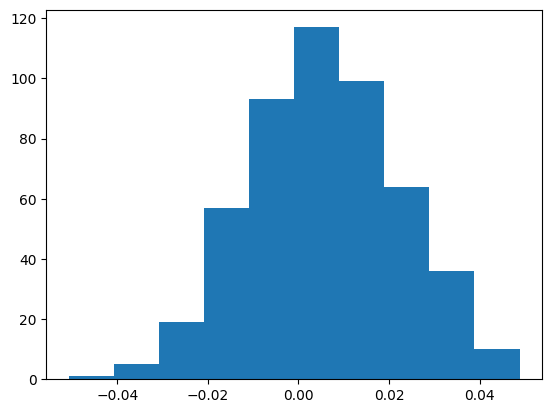

In [24]:
plt.hist(values)

In [38]:
# Loading the configuration to reconstruct the ansatz
with open(f"{path}/config.json") as f:
    config = json.load(f)

print(config)

{'nqubits': 20, 'nlayers': 5, 'b': 1.2566370614359172, 'theta': 1.5707963267948966, 'replacement_probability': 0.7, 'ncircuits': 500, 'random_seed': 42, 'local_pauli_noise_sigma': 0.003, 'max_bond_dimension': 128, 'nruns': 10, 'plot': True, 'save_results': True}


In [42]:
# Load all the executed circuits' parameters
circuit_params = []
for i in range(500):
    circuit_params.append(np.load(f"{path}/circuits/params_circuit{i}.npy"))

In [47]:
# Construct Floquet inspired ansatz and related transpiled one
floq_ansatz = FloquetAnsatz(
    nqubits=config["nqubits"],
    nlayers=config["nlayers"],
    b=config["b"],
    theta=config["theta"],
)

print(len(floq_ansatz.circuit.get_parameters()))
# Because it works with transpiled for now
transpiled_ansatz = TranspiledAnsatz(original_circuit=floq_ansatz.circuit)
print(len(transpiled_ansatz.circuit.get_parameters()))

951
2472


In [44]:
# Construct observable
# Target qubit
q = int(config["nqubits"]/2)
obs = "I" * (q) + "X" + "I" * (config["nqubits"] - (q + 1))
print(obs)

IIIIIIIIIIXIIIIIIIII


In [23]:
# Construct hybrid surrogate and test it
hs = HybridSurrogate(ansatz=transpiled_ansatz)

# repl_prob = 0. means we leave it as it is
expval, _  = hs.expectation_from_partition(
    observable=obs,
    replacement_probability=0.,
)

print(expval)

9.8945569944736e-15


In [22]:
# Construct the symbolic form from the observable pauli operators
form = 1
for i, pauli in enumerate(obs):
    form *= getattr(symbols, pauli)(i)

# The correspondent hamiltonian
ham = hamiltonians.SymbolicHamiltonian(form)
# And execute expval as double check
ham.expectation(hs.ansatz.circuit().state())

np.float64(4.83224783414539e-18)

In [27]:
s = [i for i in range(30)]
s[10:20]

[10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

In [31]:
len(circuit_params)

10

#### Compute exact expectation values using our simulator

In [ ]:
exact_values = []
for par in circuit_params[10:25]:
    # Update Floquet ansatz
    floq_ansatz.circuit.set_parameters(par)
    tran_ansatz = TranspiledAnsatz(original_circuit=floq_ansatz.circuit)
    # Construct surrogate
    hs = HybridSurrogate(tran_ansatz)
    # Compute expectation value
    exact_val = hs.expectation_from_partition(observable=obs, replacement_probability=0.)[0]
    exact_values.append(exact_val)
    print(f"Exact value for params {i+1}/15: {exact_val}")

In [35]:
def line(x, a, b):
    """Linear ansatz"""
    return x * a + b

def plot_mitigation(exact_values, noisy_values, line_params=None):
    """Plot mitigation results"""
    plt.figure(figsize=(5, 5*6/8), dpi=100)
    plt.scatter(noisy_values, exact_values, color="purple", label="Data")
    if line_params is not None:
        x = np.linspace(min(noisy_values), max(noisy_values), 100)
        y = line(x, *line_params)
        plt.plot(x, y, color="black", label="Fit", ls="-")
    plt.xlabel("IBM hardware")
    plt.ylabel("Exact")
    plt.legend()
    plt.grid()

In [36]:
len(exact_values), len(values[1:])
exact_values, values[1:]

([0.023786599752982758,
  0.20121103648875704,
  0.2772521249621558,
  -0.09526064282252943,
  0.29915821352156224,
  0.2815942405179772,
  0.1537433216466405,
  0.023240041290655232,
  0.012114047817134474,
  0.1497977983779658],
 [array(-0.11472181),
  array(0.24766125),
  array(0.1629739),
  array(0.03545052),
  array(0.192516),
  array(0.24667651),
  array(-0.08025603),
  array(0.04677499),
  array(-0.01871),
  array(0.10585918)])

In [37]:
# Adopt a linear map and fit the data
popt, pcov = curve_fit(line, values[1:], exact_values)

In [38]:
popt

array([0.72798651, 0.07266125])

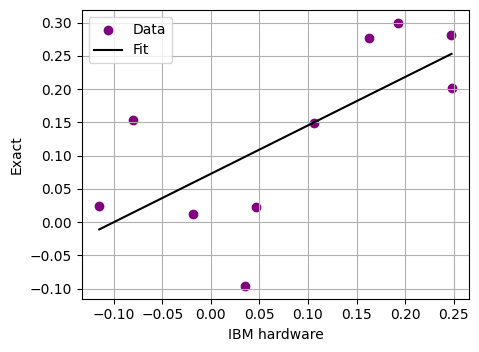

In [39]:
# Show the results in a plot
plot_mitigation(exact_values, values[1:], popt)

In [40]:
# Show the results in numbers
noisy_value = values[5]
exact_value = exact_values[5]

print(f"Noisy: {noisy_value}")
print(f"Exact: {exact_value}")
print(f"Mitig: {line(noisy_value, *popt)}")
print(f"\nMSE noisy: {(noisy_value-exact_value)**2}")
print(f"MSE mitig: {(line(noisy_value, *popt)-exact_value)**2}")

Noisy: 0.19251600196947316
Exact: 0.2815942405179772
Mitig: 0.21281029750902694

MSE noisy: 0.007934932582904192
MSE mitig: 0.004731230815858519


In [41]:
floq_ansatz = FloquetAnsatz(
    nqubits=45,
    nlayers=5,
    b=config["b"],
    theta=config["theta"],
)

In [42]:
print(floq_ansatz.circuit.summary())

Circuit depth = 102
Total number of gates = 3082
Number of qubits = 45
Most common gates:
rz: 1321
rx: 880
cx: 880
h: 1


In [43]:
len(floq_ansatz.circuit.get_parameters())

2201